# Sheet 5 - Maximum likelihood estimation in point-process data

# 5.1 Power-law fluence distribution of fast radio bursts

A radio survey detects $N$ fast radio bursts above a fluence threshold $S_{\min}$. Define
$$
x \equiv S/S_{\min} \ge 1,
$$
and model the detections as an inhomogeneous Poisson process with
$$
\phi(x;\boldsymbol{\theta}) = \frac{\mathrm{d}N}{\mathrm{d}x} = A\,x^{-\gamma}, \qquad \gamma > 1,
$$
for parameters $\boldsymbol{\theta}=(A,\gamma)^\top$.

**a.** Evaluate $\bar N(\boldsymbol{\theta})$ and write $\ell$ explicitly. Why does $\gamma>1$ matter?

$$
\bar N = \int_1^\infty A x^{-\gamma}\,\mathrm{d}x = \frac{A}{\gamma-1},
\qquad
\ell(A,\gamma) = -\frac{A}{\gamma-1} + N\ln A - \gamma\sum_{i=1}^N \ln x_i.
$$

The integral converges only for $\gamma>1$; otherwise the expected number of events diverges at large $x$. See the derivation of the original likelihood of the Poisson process in the [video](https://www.youtube.com/watch?v=JSqXUYrCACQ).

**b.** Derive the MLEs $\hat A$ and $\hat\gamma$.

From the score equations:
$$
\frac{\partial\ell}{\partial A} = -\frac{1}{\gamma-1} + \frac{N}{A}=0
\quad\Rightarrow\quad
A = N(\gamma-1),
$$
$$
\frac{\partial\ell}{\partial\gamma} = \frac{A}{(\gamma-1)^2} - \sum_i \ln x_i = 0.
$$
Insert the first result into the second:
$$
\hat\gamma = 1 + \frac{N}{\sum_i \ln x_i},
\qquad
\hat A = N(\hat\gamma-1) = \frac{N^2}{\sum_i \ln x_i}.
$$

**c.** Is $\hat\gamma$ unbiased?

Distribution of $y_i = \ln x_i$. From the problem setup the conditional density of each event location is
$$
p(x) = \frac{\phi(x)}{\bar N} = (\gamma-1)\,x^{-\gamma}, \quad x \ge 1.
$$
Under the change of variables $y = \ln x$ (so $x=e^y$, $\mathrm{d}x = e^y\mathrm{d}y$):
$$
p_Y(y) = p_X(e^y) e^y
= (\gamma-1)\,e^{-\gamma y} e^{y}
= (\gamma-1)\,e^{-(\gamma-1)y}, \quad y \ge 0,
$$
i.e. $y_i \sim \mathrm{Exp}(\gamma-1)$ iid (exponential distribution). Since this occurs as a sum, we have another new random variable
$G = \sum_{i=1}^N y_i$ which itself is then $\Gamma$ distributed:
$$
G \sim \mathrm{Gamma}(N,\,\text{rate}=\gamma-1).
$$

In the equation for $\hat\gamma$, $G$ occurs in the denominator, however. So we need to calculate:

$$
\mathbb{E}(1/G) = \int \mathrm{d}x \frac{(\gamma - 1)^N}{\Gamma(N)}x^{N-1} \mathrm{e}^{-(\gamma -1)x}/x = \frac{(\gamma - 1)^N}{\Gamma(N)}\int \mathrm{d}x\; x^{N-2} \mathrm{e}^{-(\gamma -1)x}
$$

The remaining integral can be solved by substituting $t = (\gamma - 1)x$:

$$
\int_0^\infty \left(\frac{t}{\gamma-1}\right)^{N-2} \mathrm{e}^{-t}  \frac{\mathrm{d}t}{\gamma-1} 
= \int_0^\infty \frac{t^{N-2}}{(\gamma-1)^{N-2}}  \mathrm{e}^{-t}  \frac{\mathrm{d}t}{\gamma-1} 
= \frac{1}{(\gamma-1)^{N-2}  (\gamma-1)} \int_0^\infty t^{N-2} \mathrm{e}^{-t} \, \mathrm{d}t 
= \frac{1}{(\gamma-1)^{N-1}} \int_0^\infty t^{N-2} \mathrm{e}^{-t} \, \mathrm{d}t = \frac{\Gamma(N-1)}{(\gamma-1)^{N-1}} 
$$

and therefore:

$$
 \mathbb{E}(1/G) = \frac{(\gamma - 1)^N}{\Gamma(N)} \frac{\Gamma(N-1)}{(\gamma-1)^{N-1}} = \frac{(\gamma-1)^N (N-2)!}{(N-1)!(\gamma-1)^{N-1}} = \frac{\gamma -1}{N-1}.
$$

Putting everything together, we find:

$$
\mathbb{E}[\hat\gamma]
= 1 + N\frac{\gamma-1}{N-1}
= 1 + \frac{N(\gamma-1)}{N-1},
$$
so that
$$
\mathrm{Bias}(\hat\gamma) = \mathbb{E}[\hat\gamma]-\gamma = \frac{\gamma-1}{N-1} > 0.
$$
$\hat\gamma$ is biased upward by $O(1/N)$, it is asymptotically unbiased.

From this expression, we can directly remove the bias by replacing $N/G$ with $(N-1)/G$:
$$
\hat\gamma_{\mathrm{bc}} = 1 + \frac{N-1}{G} = 1 + \frac{N-1}{N}(\hat\gamma-1).
$$

**d.** Derive and evaluate the Fisher matrix.

For an inhomogeneous Poisson process the Fisher information matrix satisfies the Poisson-process Fisher identity:
$$
{F_{ab}(\boldsymbol{\theta}) = \int_{\mathcal{X}} \frac{1}{\phi(x;\boldsymbol{\theta})} \frac{\partial\phi}{\partial\theta_a} \frac{\partial\phi}{\partial\theta_b}\,\mathrm{d}x = \int_{\mathcal{X}} \phi\,\partial_a\!\ln\phi\,\partial_b\!\ln\phi\,\mathrm{d}x.}
$$

This can be derived by starting from the score of the log-likelihood:
$$
\partial_a \ell = -\int_{\mathcal{X}} \partial_a\phi\,\mathrm{d}x + \sum_{i=1}^N \partial_a\ln\phi(x_i).
$$
Differentiating once more with respect to $\theta_b$:
$$
\partial_a\partial_b\ell = -\int_{\mathcal{X}} \partial_a\partial_b\phi\,\mathrm{d}x + \sum_{i=1}^N \left[\frac{\partial_a\partial_b\phi(x_i)}{\phi(x_i)} - \frac{\partial_a\phi(x_i)\,\partial_b\phi(x_i)}{\phi(x_i)^2}\right].
$$
Now take the expectation using for a Poisson process with intensity $\phi$, any sum over observed events satisfies
$$
\mathbb{E}\!\left[\sum_{i=1}^N g(x_i)\right] = \int_{\mathcal{X}} \phi(x)\,g(x)\,\mathrm{d}x.
$$
Applying this to each sum:
$$
\mathbb{E}[\partial_a\partial_b\ell]
= -\int\partial_a\partial_b\phi\,\mathrm{d}x
+ \int\partial_a\partial_b\phi\,\mathrm{d}x
- \int\frac{\partial_a\phi\,\partial_b\phi}{\phi}\,\mathrm{d}x
= -\int\frac{\partial_a\phi\,\partial_b\phi}{\phi}\,\mathrm{d}x.
$$
The first two terms cancel exactly, leaving
$$
F_{ab} = -\mathbb{E}[\partial_a\partial_b\ell] = \int_{\mathcal{X}}\frac{\partial_a\phi\,\partial_b\phi}{\phi}\,\mathrm{d}x = \int_{\mathcal{X}}\phi\,\partial_a\!\ln\phi\,\partial_b\!\ln\phi\,\mathrm{d}x.
$$
This is structurally identical to the standard Fisher identity $F_{ab}=\int p\,\partial_a\!\ln p\,\partial_b\!\ln p$ — the intensity $\phi$ plays the role of the probability density $p$, with the key difference that $\phi$ need not integrate to unity.


Now let's calculate the Fisher matrix directly:
$$
\partial_A\ln\phi = \frac{1}{A},
\qquad
\partial_\gamma\ln\phi = -\ln x.
$$
Using $s\equiv\gamma-1$ and the integral identity $\int_1^\infty x^{-\gamma}(\ln x)^k\,\mathrm{d}x = k!/s^{k+1}$:
$$
F_{AA} = \int_1^\infty \phi\frac{1}{A^2}\,\mathrm{d}x = \frac{1}{A}\int_1^\infty x^{-\gamma}\,\mathrm{d}x = \frac{1}{As},
$$
$$
F_{A\gamma} = \int_1^\infty \phi\frac{1}{A}(-\ln x)\,\mathrm{d}x = -\int_1^\infty x^{-\gamma}\ln x\,\mathrm{d}x = -\frac{1}{s^2},
$$
$$
F_{\gamma\gamma} = \int_1^\infty \phi(\ln x)^2\,\mathrm{d}x = A\int_1^\infty x^{-\gamma}(\ln x)^2\,\mathrm{d}x = \frac{2A}{s^3}.
$$
So
$$
F(A,\gamma) =
\begin{pmatrix}
\dfrac{1}{A(\gamma-1)} & -\dfrac{1}{(\gamma-1)^2} \\[6pt]
-\dfrac{1}{(\gamma-1)^2} & \dfrac{2A}{(\gamma-1)^3}
\end{pmatrix}.
$$

**e.** Let us invert the Fisher matrix to obtain the covariance:


$$
F^{-1} =
\begin{pmatrix}
2A(\gamma-1) & (\gamma-1)^2 \\
(\gamma-1)^2 & \dfrac{(\gamma-1)^3}{A}
\end{pmatrix}.
$$
Hence
$$
\sigma^2_{\hat A} = 2A(\gamma-1),
\qquad
\sigma^2_{\hat\gamma} = \frac{(\gamma-1)^3}{A}.
$$
The correlation coefficient is
$$
\rho_{A\gamma} = \frac{(F^{-1})_{A\gamma}}{\sqrt{(F^{-1})_{AA}(F^{-1})_{\gamma\gamma}}} = \frac{1}{\sqrt{2}}.
$$
It is parameter-independent.

**f.** Reparametrise to $(\bar N,\gamma)$ and interpret.

Define new parameters $\boldsymbol{\eta} = (\bar N,\gamma)^\top$ via $\bar N = A/(\gamma-1)$, i.e.\ $A = \bar N(\gamma-1)$.  Under a reparametrisation $\boldsymbol{\theta}\to\boldsymbol{\eta}(\boldsymbol{\theta})$, the Fisher matrix transforms as
$$
F(\boldsymbol{\eta}) = J^\top\, F(\boldsymbol{\theta})\, J,
\qquad
J_{ij} = \frac{\partial\theta_i}{\partial\eta_j}
\quad\text{(Jacobian of old w.r.t.\ new parameters).}
$$
Computing the partial derivatives of $(A,\gamma)$ with respect to $(\bar N,\gamma)$:
$$
\frac{\partial A}{\partial\bar N} = \gamma-1 = s,
\qquad
\frac{\partial A}{\partial\gamma} = \bar N,
\qquad
\frac{\partial\gamma}{\partial\bar N} = 0,
\qquad
\frac{\partial\gamma}{\partial\gamma} = 1,
$$
so the Jacobian matrix is
$$
J = \frac{\partial(A,\gamma)}{\partial(\bar N,\gamma)} =
\begin{pmatrix}
s & \bar N \\
0 & 1
\end{pmatrix}.
$$
Substituting $A = \bar N s$ into $F(A,\gamma)$ and carrying out $J^\top F J$:

$$
F(\bar N,\gamma) =
\begin{pmatrix} s & 0 \\ \bar N & 1 \end{pmatrix}
\begin{pmatrix} \dfrac{1}{\bar N s^2} & -\dfrac{1}{s^2} \\[6pt] -\dfrac{1}{s^2} & \dfrac{2\bar N}{s^2} \end{pmatrix}
\begin{pmatrix} s & \bar N \\ 0 & 1 \end{pmatrix}.
$$

The off-diagonal entry of the product $F(A,\gamma)\,J$ is
$$
\bigl[F(A,\gamma)\,J\bigr]_{12}
= \frac{1}{\bar N s^2} \bar N + \Bigl(-\frac{1}{s^2}\Bigr) 1
= \frac{1}{s^2} - \frac{1}{s^2} = 0,
$$
so the two terms cancel exactly and the transformed matrix is diagonal:
$$
F(\bar N,\gamma) =
\begin{pmatrix}
\dfrac{1}{\bar N} & 0 \\[6pt]
0 & \dfrac{\bar N}{(\gamma-1)^2}
\end{pmatrix}.
$$
Total-count information and shape information decouple completely in this parametrisation; the $A$-$\gamma$ correlation seen in $F(A,\gamma)$ is a pure coordinate effect.

**g.** Visualise the likelihood in 1D and 2D

Define
$$
\Delta\chi^2(A,\gamma) \equiv -2\left[\ell(A,\gamma)-\ell(\hat A,\hat\gamma)\right],
$$
with
$$
\ell(A,\gamma) = -\frac{A}{\gamma-1} + N\ln A - \gamma\sum_{i=1}^N\ln x_i.
$$

From the MLE equations,
$$
\hat\gamma = 1 + \frac{N}{\sum_i\ln x_i},
\qquad
\hat A = N(\hat\gamma-1).
$$

For the numbers used in the exercise ($N=100$, $\sum_i\ln x_i=66.7$):
$$
\hat\gamma\approx 2.50,
\qquad
\hat A\approx 150.
$$

1D slices requested in the sheet:
$$
\Delta\chi^2_A(A) = \Delta\chi^2(A,\hat\gamma),
\qquad
\Delta\chi^2_\gamma(\gamma) = \Delta\chi^2(\hat A,\gamma).
$$
Draw horizontal lines at $\Delta\chi^2=1$ and $\Delta\chi^2=4$ for the 68% and 95% 1D thresholds.

2D contour plot requested in the sheet:
- Evaluate $\Delta\chi^2(A,\gamma)$ on a grid around $(\hat A,\hat\gamma)$.
- Draw contours at $\Delta\chi^2=2.30$ and $\Delta\chi^2=5.99$ (68% and 95% for two parameters).

Near the maximum, use the quadratic expansion
$$
\Delta\chi^2 \simeq (\Delta\boldsymbol{\theta})^\top F\,(\Delta\boldsymbol{\theta}),
\qquad
\Delta\boldsymbol{\theta}=(A-\hat A,\,\gamma-\hat\gamma)^\top,
$$
so the contours are ellipses. Because
$$
\rho_{A\gamma}=\frac{1}{\sqrt{2}}>0,
$$
the major axis is tilted with positive slope in the $(A,\gamma)$ plane. For a discussion of the contours also see the [video](https://www.youtube.com/watch?v=JSqXUYrCACQ).

python(98533) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98544) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98545) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98546) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98547) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98548) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(98549) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


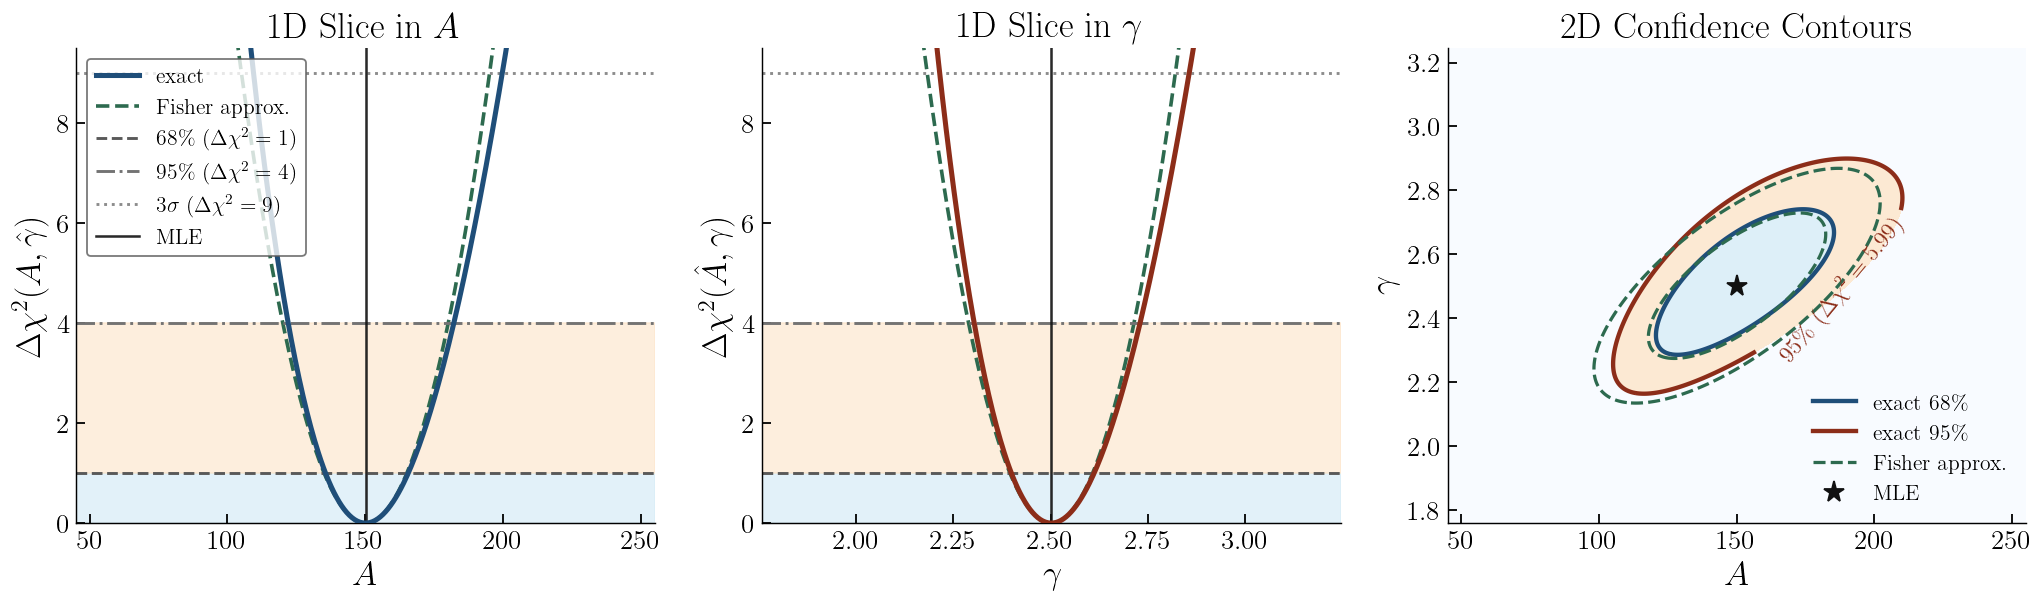

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import shutil
from matplotlib.lines import Line2D

# Consistent plot style with other solution notebooks
fontsi = 15
fontsi2 = 20
if shutil.which('latex') is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']
plt.rc('font', family='serif')
plt.rcParams.update({
    'font.size': fontsi,
    'axes.titlesize': fontsi2,
    'axes.labelsize': fontsi2 - 1,
    'xtick.labelsize': fontsi,
    'ytick.labelsize': fontsi,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'legend.frameon': False,
    'figure.dpi': 130,
})

N = 100
S = 66.607  # sum_i ln x_i

g_hat = 1.0 + N / S
A_hat = N * (g_hat - 1.0)

def ell(A, g):
    return -A / (g - 1.0) + N * np.log(A) - g * S

def delta_chi2(A, g):
    return -2.0 * (ell(A, g) - ell(A_hat, g_hat))

# Fisher matrix at MLE: F evaluated at (A_hat, g_hat)
s_hat = g_hat - 1.0
F_AA = 1.0 / (A_hat * s_hat)
F_Ag = -1.0 / s_hat**2
F_gg = 2.0 * A_hat / s_hat**3

# Profile 1-sigma from Fisher (other parameter fixed at MLE)
sigma_A = 1.0 / np.sqrt(F_AA)  # = sqrt(A_hat * s_hat)
sigma_g = 1.0 / np.sqrt(F_gg)  # = sqrt(s_hat^3 / (2*A_hat))

# Grid covers ±3σ so the 3-sigma contour (Δχ²=9) sits at the boundary
A_grid = np.linspace(max(A_hat - 7.0 * sigma_A, 1e-3), A_hat + 7.0 * sigma_A, 450)
g_grid = np.linspace(max(g_hat - 7.0 * sigma_g, 1.0), g_hat + 7.0 * sigma_g, 450)
AA, GG = np.meshgrid(A_grid, g_grid)
D2 = np.clip(delta_chi2(AA, GG), 0.0, None)

# 1D slices
D2_A = np.clip(delta_chi2(A_grid, g_hat), 0.0, None)
D2_g = np.clip(delta_chi2(A_hat, g_grid), 0.0, None)

# Quadratic (Fisher) approximation to Delta-chi2
D2_A_fisher = F_AA * (A_grid - A_hat)**2
D2_g_fisher = F_gg * (g_grid - g_hat)**2
dA, dg = AA - A_hat, GG - g_hat
D2_fisher = F_AA * dA**2 + 2.0 * F_Ag * dA * dg + F_gg * dg**2

# Color palette
c_main   = '#1f4e79'
c_aux    = '#8c2d19'
c_fisher = '#2d6a4f'
c68  = '#d9edf7'
c95  = '#fde6cc'
c_mle    = '#111111'

fig, ax = plt.subplots(1, 3, figsize=(16.0, 4.9))

# Panel 1: Delta-chi2 as a function of A at fixed gamma_hat
ax[0].axhspan(0.0, 1.0, color=c68, alpha=0.75, zorder=0)
ax[0].axhspan(1.0, 4.0, color=c95, alpha=0.65, zorder=0)
ax[0].plot(A_grid, D2_A, lw=2.8, color=c_main, zorder=3, label=r'exact')
ax[0].plot(A_grid, D2_A_fisher, lw=2.0, color=c_fisher, ls='--', zorder=2, label=r'Fisher approx.')
ax[0].axhline(1.0, ls='--', lw=1.6, c='0.35', label=r'$68\%\ (\Delta\chi^2=1)$')
ax[0].axhline(4.0, ls='-.', lw=1.6, c='0.45', label=r'$95\%\ (\Delta\chi^2=4)$')
ax[0].axhline(9.0, ls=':', lw=1.6, c='0.55', label=r'$3\sigma\ (\Delta\chi^2=9)$')
ax[0].axvline(A_hat, color=c_mle, lw=1.4, alpha=0.9, label=r'MLE')
ax[0].set_xlim(A_grid.min(), A_grid.max())
ax[0].set_ylim(0.0, 9.5)
ax[0].set_xlabel(r'$A$')
ax[0].set_ylabel(r'$\Delta\chi^2(A,\hat{\gamma})$')
ax[0].set_title(r'1D Slice in $A$')
ax[0].legend(loc='upper left', fontsize=fontsi - 3,frameon=True, edgecolor='0.35')

# Panel 2: Delta-chi2 as a function of gamma at fixed A_hat
ax[1].axhspan(0.0, 1.0, color=c68, alpha=0.75, zorder=0)
ax[1].axhspan(1.0, 4.0, color=c95, alpha=0.65, zorder=0)
ax[1].plot(g_grid, D2_g, lw=2.8, color=c_aux, zorder=3)
ax[1].plot(g_grid, D2_g_fisher, lw=2.0, color=c_fisher, ls='--', zorder=2)
ax[1].axhline(1.0, ls='--', lw=1.6, c='0.35')
ax[1].axhline(4.0, ls='-.', lw=1.6, c='0.45')
ax[1].axhline(9.0, ls=':', lw=1.6, c='0.55')
ax[1].axvline(g_hat, color=c_mle, lw=1.4, alpha=0.9)
ax[1].set_xlim(g_grid.min(), g_grid.max())
ax[1].set_ylim(0.0, 9.5)
ax[1].set_xlabel(r'$\gamma$')
ax[1].set_ylabel(r'$\Delta\chi^2(\hat{A},\gamma)$')
ax[1].set_title(r'1D Slice in $\gamma$')

# Panel 3: 2D confidence contours
dchi2_68 = 2.30
dchi2_95 = 5.99
ax[2].set_facecolor('#f8fbff')
ax[2].contourf(
    AA, GG, D2,
    levels=[0.0, dchi2_68, dchi2_95],
    colors=[c68, c95],
    alpha=0.85
)
cs = ax[2].contour(
    AA, GG, D2,
    levels=[dchi2_68, dchi2_95],
    colors=[c_main, c_aux],
    linewidths=2.4
)
ax[2].clabel(
    cs,
    fmt={
        dchi2_68: r'$68\%\ (\Delta\chi^2=2.30)$',
        dchi2_95: r'$95\%\ (\Delta\chi^2=5.99)$',
    },
    inline=True,
    fontsize=fontsi - 2,
 )
ax[2].contour(
    AA, GG, D2_fisher,
    levels=[dchi2_68, dchi2_95],
    colors=[c_fisher],
    linewidths=1.8,
    linestyles='--'
)
ax[2].plot(A_hat, g_hat, marker='*', color=c_mle, markersize=12)
ax[2].set_xlim(A_grid.min(), A_grid.max())
ax[2].set_ylim(g_grid.min(), g_grid.max())
ax[2].set_xlabel(r'$A$')
ax[2].set_ylabel(r'$\gamma$')
ax[2].set_title(r'2D Confidence Contours')

legend_handles = [
    Line2D([0], [0], color=c_main, lw=2.4, label=r'exact $68\%$'),
    Line2D([0], [0], color=c_aux,  lw=2.4, label=r'exact $95\%$'),
    Line2D([0], [0], color=c_fisher, lw=1.8, ls='--', label=r'Fisher approx.'),
    Line2D([0], [0], marker='*', color=c_mle, lw=0, markersize=12, label=r'MLE'),
]
ax[2].legend(handles=legend_handles, loc='lower right', fontsize=fontsi - 3)

for a in ax:
    a.tick_params(direction='in', length=5, width=1.0)

plt.tight_layout()
plt.show()